__Load packages__

In [1]:
#packages used
import requests
import os
import pandas as pd

import seaborn as sb
import matplotlib.pyplot as plt
%matplotlib inline
#from fpdf import FPDF #-tocompile a PDF analysis report

https://www.youtube.com/watch?v=NCoQNa2AgkY&list=WL&index=5

https://towardsdatascience.com/web-scraping-basics-82f8b5acd45c

https://www.autotrader.co.za/cars-for-sale/suzuki/jimny?pagenumber=15

https://sur.ly/o/curl.trillworks.com

__TO DO: Assess and clean the data. Analyse the data and provide a 1 page PDF analysis report__

__NB:Before cleaning make a copy of the dataframe__

## Data Gathering

use Request library to download car details from Autotrader

In [2]:
#start session
sess = requests.session()

In [3]:
#API request url
url = 'https://website-elastic-api.webuycars.co.za/api/search'

In [4]:
#Define header for POST request
headers = {'user-agent':
           'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/107.0.0.0 Safari/537.36 Edg/107.0.1418.52'}

In [5]:
#payload for the request form

n = 1824

for i in range(0, n, 23):
    form_data = {
  "to": i,
  "size": n,
  "type": "Vehicle",
  "filter_type": "all",
  "subcategory": "Hatchback",
  "q": "",
  "Make": None,
  "Roadworthy": None,
  "Auctions": [],
  "Model": None,
  "Variant": None,
  "Province": None,
  "DealerKey": None,
  "FuelType": None,
  "Fuel_Consumption_Gte": 0,
  "Fuel_Consumption_Lte": 0,
  "BodyType": None,
  "Gearbox": None,
  "AxleConfiguration": None,
  "Colour": None,
  "FinanceGrade": None,
  "Priced_Amount_Gte": 0,
  "Priced_Amount_Lte": 0,
  "MonthlyInstallment_Amount_Gte": 0,
  "MonthlyInstallment_Amount_Lte": 0,
  "auctionDate": None,
  "auctionEndDate": None,
  "auctionDurationInSeconds": None,
  "Kilometers_Gte": 0,
  "Kilometers_Lte": 0,
  "Priced_Amount_Sort": "",
  "Bid_Amount_Sort": "",
  "Kilometers_Sort": "",
  "Year_Sort": "",
  "Fuel_Consumption_Sort": "",
  "Auction_Date_Sort": "",
  "Auction_Lot_Sort": "",
  "Year": None,
  "Price_Update_Date_Sort": "",
  "Online_Auction_Date_Sort": "",
  "Online_Auction_In_Progress": "",
}
    
    #HTTP POST request
    request_data = sess.post(url, headers = headers, json = form_data)
    
    #read data back as json
    car_trader_json = request_data.json()
    
    if i == 0:
        #extract the data key from the first dictionary and create data frame
        car_trader = pd.DataFrame.from_dict(car_trader_json['data'])
    else:
        
        #extract the data key from the dictionary and append to existing dataframe
        car_trader_tmp = pd.DataFrame.from_dict(car_trader_json['data'])
        car_trader = car_trader.append(car_trader_tmp,ignore_index=True)


In [6]:
car_trader.shape

(1920, 92)

In [7]:
#save data as a spreadsheet
#car_trader.to_csv('weBuyCars.csv')

the contents of the request above brings back 25 vehicles

_________

## Assess the data

In [8]:
#print the data frame information
car_trader.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1920 entries, 0 to 1919
Data columns (total 92 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   DataTimestamp                   1920 non-null   object 
 1   Category                        1920 non-null   object 
 2   Subcategory                     1920 non-null   object 
 3   Colour                          1920 non-null   object 
 4   Condition                       1920 non-null   object 
 5   DealerKey                       1920 non-null   object 
 6   BranchCode                      1920 non-null   object 
 7   Province                        1920 non-null   object 
 8   Description                     1920 non-null   object 
 9   Make                            1920 non-null   object 
 10  Model                           1920 non-null   object 
 11  Mileage                         1920 non-null   int64  
 12  OnlineDescription               19

In [9]:
#print the number of null values in the dataframe
car_trader.isnull().sum().sort_values(ascending = False).head(40)

VehicleStatus                     1919
VideoReviewUrl                    1894
Wheelbase                         1867
Eval_Maintenance_Expiry           1866
Eval_Warranty_Expiry              1762
SearchTag                         1577
auctionStartDate                  1537
auctionDurationInHours            1537
auctionDurationInSeconds          1537
auctionId                         1537
auctionStartDateTime              1537
auctionEndDate                    1537
lotCategory                       1537
reservePrice                      1537
reservePriceMet                   1537
totalNumberOfBids                 1537
auction                           1537
TurboOrSuperCharged               1211
GCM                                989
CO2                                370
GVM                                248
Width                               97
RearTyreSize                        58
FuelConsumption                     53
FrontTyreSize                       44
FuelTankSize             

- features with most null values are realted to auctions and this because a few number of cars areon auction
- about 281 vehicles are/have been on auction

In [10]:
#vehicles with no auction id
car_trader.auctionId.isnull().sum()

1537

In [11]:
#most cars's driver is in front
car_trader.Drive.describe()

count     1919
unique       3
top          F
freq      1818
Name: Drive, dtype: object

In [12]:
#most cars 5 gears
car_trader.NoGears.describe()

count     1916
unique       7
top          5
freq      1203
Name: NoGears, dtype: object

- some features containing numbers are stored as strings

In [13]:
#using summary statistics to detect the mean, min and max values of the entire dataset
car_trader.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Mileage,1920.0,115980.027083,71177.021176,0.0,63000.0,110000.0,155000.0,563000.00
Price,1920.0,132252.083333,84793.191050,14900.0,72900.0,114900.0,172900.0,788900.00
Year,1920.0,2013.895833,5.004801,1983.0,2011.0,2014.0,2018.0,2022.00
FuelConsumption,1867.0,5.931221,1.253381,3.3,5.0,5.8,6.4,11.56
OpeningBid,1920.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.00
BuyNowPrice,1920.0,132252.083333,84793.191050,14900.0,72900.0,114900.0,172900.0,788900.00
MonthlyInstalment,1920.0,2471.842708,1413.759496,515.0,1482.0,2183.0,3150.0,13420.00
PreviousPrice,1920.0,136020.885417,87408.941535,16900.0,75900.0,117900.0,175900.0,798900.00
RoadworthyRelevantIssues,1907.0,2.657053,3.206083,0.0,0.0,2.0,4.0,24.00
DefaultSortOrder,1920.0,2587.136458,1936.829464,0.0,943.0,2225.0,3990.0,6934.00


- from the summary statistics

In [14]:
print(car_trader.Eval_Warranty_Active.unique())
print(car_trader.Make.unique())
print(car_trader.Eval_Maintenance_Active.unique())
print(car_trader.Eval_Warranty_Active.unique())
print(car_trader.Eval_ServiceHistory.unique())

[False  True]
['Hyundai' 'KIA' 'Renault' 'Volkswagen' 'Toyota' 'Suzuki' 'Opel' 'Datsun'
 'Chevrolet' 'Ford' 'Bajaj' 'Honda' 'Baic' 'Fiat' 'GWM' 'Mazda' 'Peugeot'
 'Nissan' 'BMW' 'Citroen' 'Daihatsu' 'Audi' 'Mitsubishi' 'Tata' 'Smart'
 'Mini' 'Volvo' 'Alfa Romeo' 'Chery' 'Mercedes-Benz' 'MG' 'Dodge' 'Proton'
 'Seat' 'Abarth' 'Lexus']
[False  True]
[False  True]
['Partial' 'Complete but Due' 'No record' 'Complete, Up To Date'
 'Partial but Up to Date' 'Unverified Service History']


In [15]:
car_trader.head().transpose()

,0,1,2,3,4
DataTimestamp,2022-12-16T12:00:02.637+00:00,2022-12-16T12:00:02.637+00:00,2022-12-16T12:00:02.637+00:00,2022-12-16T12:00:02.637+00:00,2022-12-16T12:00:02.637+00:00
Category,Vehicle,Vehicle,Vehicle,Vehicle,Vehicle
Subcategory,Hatchback,Hatchback,Hatchback,Hatchback,Hatchback
Colour,Grey,Blue,Blue,Silver,Silver
Condition,Shows signs of excessive wear and tear,Normal wear and tear,Normal wear and tear,Vehicle in excellent condition,Vehicle in excellent condition
...,...,...,...,...,...
auction,NaN,NaN,NaN,NaN,NaN
VideoReviewUrl,NaN,NaN,NaN,NaN,NaN
TurboOrSuperCharged,NaN,NaN,NaN,NaN,NaN
Wheelbase,NaN,NaN,NaN,NaN,NaN


# What is the structure of your dataset?
The data is scraped from [WeBuyCars]("https://www.webuycars.co.za/buy-a-car") car dealership for second hand hatchback vehicles. The data is stored in a csv file and contains 92 columns and 1920 rows. The car models range from 1986 to 2022.

Each vehicle's data such as make, model, mileage, colour and its condition are included. The data contains the car dealership details and the prices of each vehicle. There are more technical details about the car like Gearbox, NoGears,	Cooling, CubicCapacity, CylConfiguration, EngineCycle, FuelTankSize, FuelType, FuelConsumption and CO2.

The auction features in the data will be out of scope of this analysis.

### What is/are the main feature(s) of interest in your dataset?

__The following are the topics I am going to explore and analyse:__

- Which car make and model is the most popular? What proportion of the makes have service, maintenance and warranty?
- Which car make and model is the best/worst when it comes to fuel consumption and CO2 emission?
- What factors affect the car price? 
- What is the distribution of the car finance grades?

### What features in the dataset do you think will help support your investigation into your feature(s) of interest?

__I will use only the following features (33)__
1. Colour	
2. Condition	
3. DealerKey	
4. BranchCode	
5. Province	
6. Year	
7. Description	
8. Make	
9. Model	
10. Mileage	
11. OnlineDescription	
12. Variant	
13. Price
14. AxleConfiguration
15. NoOfDoors
16. Seats
17. Gearbox	
18. NoGears	
19. Cooling
20. FuelType	
21. FuelConsumption
22. CO2
23. FinanceGrade	
24. PricingGrade
25. PreviousPrice	
26. LatestDekraInspectionCreatedOn	
27. HasAnyRoadworthyRelevantIssues
28. RoadworthyRelevantIssues	
29. Eval_ServiceHistory
30. Eval_Maintenance_Active	
31. Eval_Warranty_Active
32. Eval_Warranty_Expiry
33. Eval_Maintenance_Expiry


In [16]:
#make copy of original datset
car_trader_df = car_trader.copy()

In [17]:
#filter relevant columns
car_trader_df = car_trader_df.filter(['Colour', 'Condition','DealerKey','BranchCode','Province','Year','Description','Make',
                              'Model','Mileage','OnlineDescription','Variant','Price','PreviousPrice','AxleConfiguration',
                              'NoOfDoors','Seats','Gearbox','NoGears','Cooling','FuelType','FuelConsumption','CO2',
                              'FinanceGrade','PricingGrade','LatestDekraInspectionCreatedOn',
                              'HasAnyRoadworthyRelevantIssues','RoadworthyRelevantIssues','Eval_ServiceHistory',
                              'Eval_Maintenance_Active','Eval_Warranty_Active',
                              'Eval_Warranty_Expiry','Eval_Maintenance_Expiry'])
car_trader_df.head().transpose()                              

,0,1,2,3,4
Colour,Grey,Blue,Blue,Silver,Silver
Condition,Shows signs of excessive wear and tear,Normal wear and tear,Normal wear and tear,Vehicle in excellent condition,Vehicle in excellent condition
DealerKey,Silver Lakes (GP),Richmond (WC),Epping (WC),Silver Lakes (GP),Brackenfell (WC)
BranchCode,SIL,RIC,EPP,SIL,CPT
Province,Gauteng,Western Cape,Western Cape,Gauteng,Western Cape
Year,2011,2016,2021,2022,2022
Description,2011 Hyundai i10 1.2 GLS,2016 KIA Picanto 1.0,2021 Renault Kwid 1.0 Dynamique / ZEN 5-Door,2022 Volkswagen Polo Vivo 1.4 Trendline (5dr),2022 Volkswagen Polo Vivo 1.4 Comfortline (5dr)
Make,Hyundai,KIA,Renault,Volkswagen,Volkswagen
Model,i10,Picanto,Kwid,Polo Vivo,Polo Vivo
Mileage,142000,25105,21239,1000,100


In [18]:
#new dataframe with reduced number of columns
car_trader_df.shape

(1920, 33)

In [19]:
#missing values in new dataframe
car_trader_df.isnull().sum()

Colour                               0
Condition                            0
DealerKey                            0
BranchCode                           0
Province                             0
Year                                 0
Description                          0
Make                                 0
Model                                0
Mileage                              0
OnlineDescription                    0
Variant                              0
Price                                0
PreviousPrice                        0
AxleConfiguration                    0
NoOfDoors                            0
Seats                                0
Gearbox                              0
NoGears                              4
Cooling                              0
FuelType                             0
FuelConsumption                     53
CO2                                370
FinanceGrade                         0
PricingGrade                         0
LatestDekraInspectionCrea

__Missing/Invalid values__
-

- 3 vehicles do not have the number of gears stated
- 50 vehicles have missing fuel consumption data
- 344 vehicles do not have their c02 emissions stated
- dekra reports are missing for 4 cars
- roadworthy issues for 3 cars are not stated, this may mean that they do not have any issues
- warranty expiry dates are not stated for 1747 vehicles, this may mean their expiry date is missing or it is in the future.
- maintenance expiry dates are not stated for 1860 vehicles, this may mean their expiry date is missing or it is in the future.


- ?

In [20]:
#data frame information
car_trader_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1920 entries, 0 to 1919
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Colour                          1920 non-null   object 
 1   Condition                       1920 non-null   object 
 2   DealerKey                       1920 non-null   object 
 3   BranchCode                      1920 non-null   object 
 4   Province                        1920 non-null   object 
 5   Year                            1920 non-null   int64  
 6   Description                     1920 non-null   object 
 7   Make                            1920 non-null   object 
 8   Model                           1920 non-null   object 
 9   Mileage                         1920 non-null   int64  
 10  OnlineDescription               1920 non-null   object 
 11  Variant                         1920 non-null   object 
 12  Price                           19

Is the data tidy?
-

- The PricingGrade column is made up of the grade type and the grade description

_________

## Cleaning the data

_________

# Data Exploration

 #### Mileage Distribution

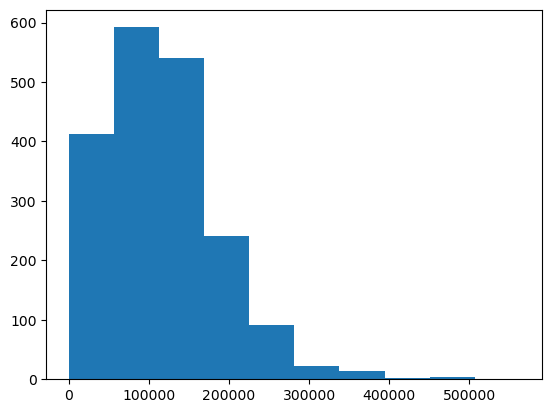

In [21]:
#the distribution of car mileage
plt.hist(car_trader_df.Mileage)
plt.show()

- The mileage data is skewed to the right.
- The distribution is bi-modal. With a spike in cars with mileage between 100 000 and 150 000 and then followed by a spike in those with mileage between 50 000 and 100 000

 #### Finance Grade Distribution

 #### Mileage and Price Distribution

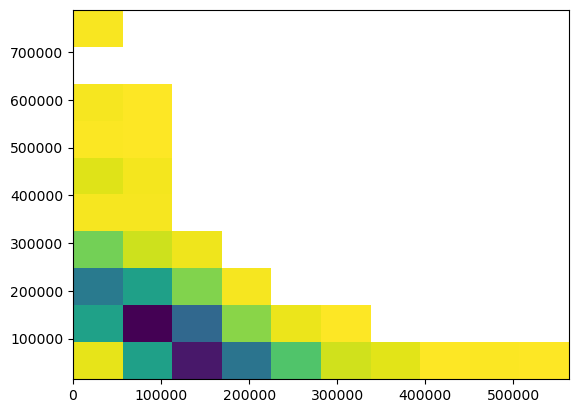

In [22]:
plt.hist2d(data = car_trader_df, x = 'Mileage', y = 'Price', cmin=0.5, cmap='viridis_r')
plt.show()

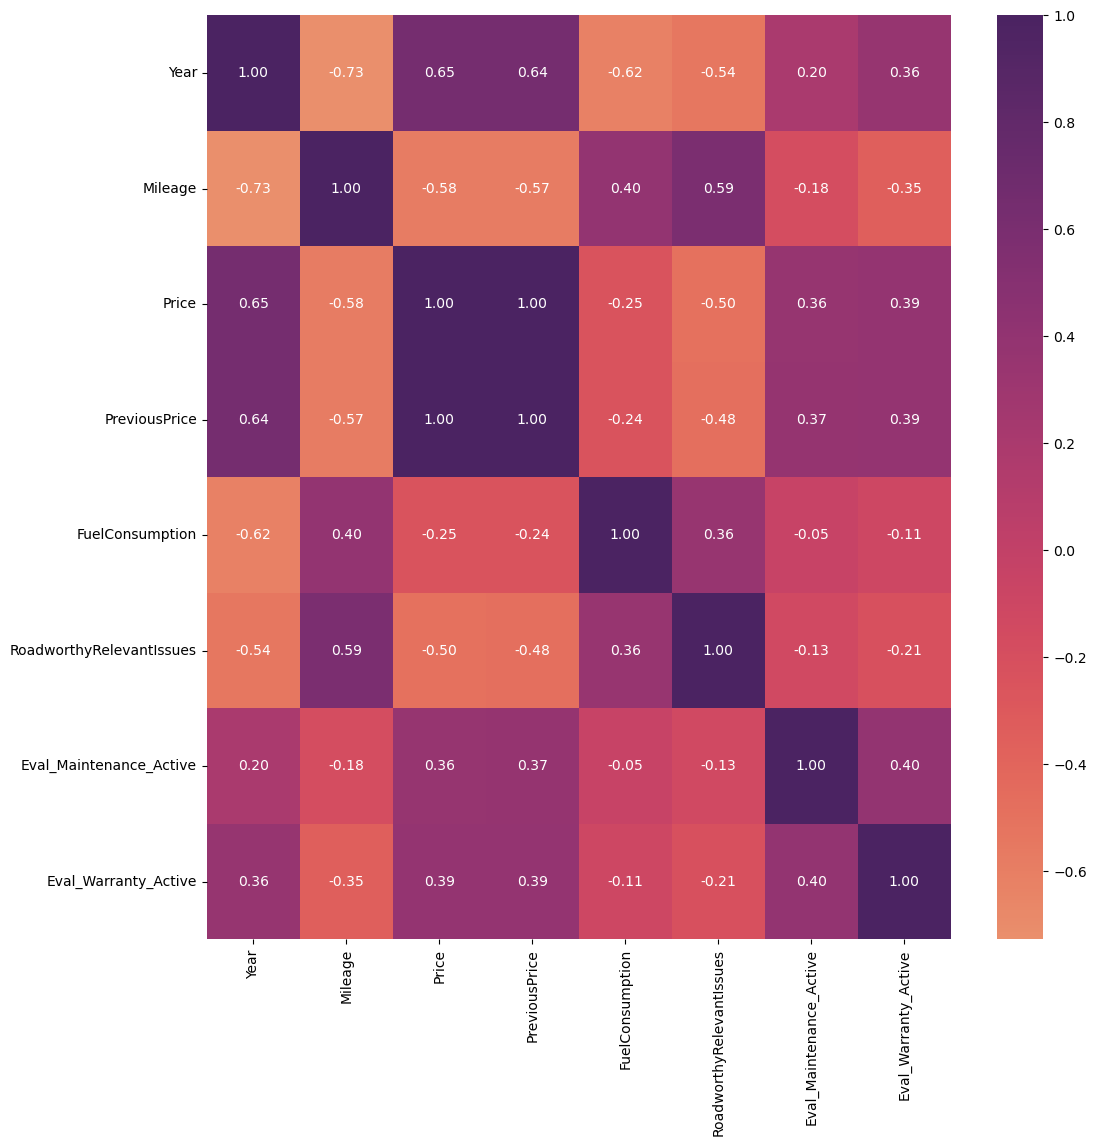

In [23]:
#dataset correlation matrix
plt.figure(figsize=[12, 12])
sb.heatmap(car_trader_df.corr(), annot = True, fmt = '.2f', cmap = 'flare', center = 0)
plt.show()

- There is positive correlation between price and year
- There exists a positive correlation between RoadworthyRelevantIssues and Mileage
- Price is closely positively correlated to PreviousPrice
- Mileage has a close negative correlation with Year
- Price also has a negative correlation with Mileage.
- There is a positive correlation between Year and Price.

_________

# Data Visualization

In [24]:
makes = car_trader_df['Make'].value_counts().head(10)
makes

Volkswagen    343
Ford          209
Hyundai       180
Renault       142
Toyota        140
Audi           96
KIA            91
Mini           90
BMW            70
Opel           68
Name: Make, dtype: int64

In [25]:
labels = makes.index
labels

Index(['Volkswagen', 'Ford', 'Hyundai', 'Renault', 'Toyota', 'Audi', 'KIA',
       'Mini', 'BMW', 'Opel'],
      dtype='object')

plt.figure(figsize=[10, 10])
p = plt.pie(makes, startangle=90, labels = labels, autopct='%1.1f%%')
plt.axis('equal')

plt.show()

In [27]:
maintenance = car_trader_df['Eval_Maintenance_Active'].value_counts()
maintenance_labels = maintenance.index

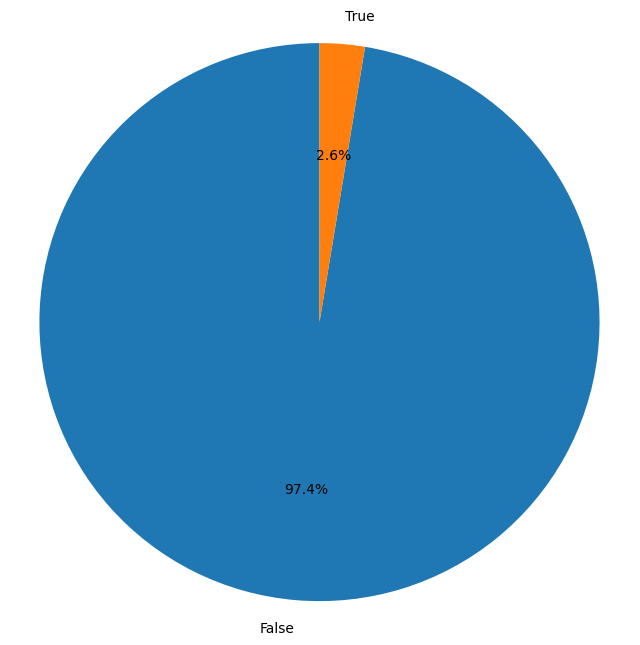

In [28]:
plt.figure(figsize=[8, 8])
p = plt.pie(maintenance, startangle=90, labels = maintenance_labels, autopct='%1.1f%%')
plt.axis('equal')

plt.show()

- A large proportion of the vehicles have no active evaluated maintenance